# Evaluación 2
## Programación Científica 2026-1

### Universidad Nacional de Colombia - Sede Medellín

---

## Estudiante

**Nombre:** Juan Esteban Osorno Duque

**ID de la evaluación:** 4879

---

# Introducción

En esta evaluación se estudia el problema de la reconstrucción de señales mediante una red neuronal de dos capas. El objetivo principal consiste en comparar dos estrategias para inicializar la primera capa de la red: una inicialización aleatoria y una inicialización basada en la Transformada de Fourier.

Las señales utilizadas fueron generadas a partir de distintos regímenes de dispersión y están compuestas por una combinación de funciones seno y coseno con diferentes frecuencias. Debido a esta estructura, resulta natural preguntarse si una representación basada en Fourier permite aprender de manera más eficiente que una representación completamente aleatoria.

A lo largo del desarrollo se analizarán las señales, se construirá la base de Fourier solicitada en el enunciado, se implementará la red neuronal en JAX y finalmente se comparará el desempeño de ambas inicializaciones mediante diferentes métricas y visualizaciones científicas.

---

## Objetivos

Los objetivos de esta evaluación son:

- Explorar y comprender la estructura del conjunto de datos suministrado.
- Construir una capa de Fourier utilizando \(K=30\) frecuencias.
- Implementar una red neuronal capaz de reconstruir las señales de entrada.
- Comparar el entrenamiento de una red inicializada aleatoriamente con otra inicializada mediante Fourier.
- Analizar la capacidad de compresión de las señales utilizando la energía acumulada de los coeficientes de Fourier.

---



# 1. Configuración del entorno de trabajo

Antes de comenzar con el análisis del conjunto de datos es necesario preparar el entorno de trabajo. En esta sección se importan las bibliotecas que serán utilizadas a lo largo de la evaluación y se configura un estilo uniforme para todas las visualizaciones científicas.

En particular:

- **NumPy** será utilizado para el manejo eficiente de arreglos y operaciones matriciales.
- **Matplotlib** permitirá construir las figuras necesarias para analizar las señales y los resultados del entrenamiento.
- Finalmente, se establece una configuración gráfica común que mejora la legibilidad de las figuras y proporciona soporte para expresiones matemáticas utilizando la sintaxis de LaTeX.

In [123]:
# Librerías principales
import numpy as np
import matplotlib.pyplot as plt

# Configuración de las gráficas
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({

    "figure.figsize": (10,5),

    "figure.dpi": 120,

    "font.family": "serif",

    "mathtext.fontset": "cm",

    "axes.titlesize": 14,

    "axes.labelsize": 12,

    "legend.fontsize": 11,

    "xtick.labelsize": 10,

    "ytick.labelsize": 10

})

# 2. Carga del conjunto de datos

Una vez configurado el entorno de trabajo, el siguiente paso consiste en cargar el conjunto de datos suministrado para esta evaluación.

El archivo se encuentra almacenado en formato **NumPy (.npz)**, el cual permite guardar múltiples arreglos dentro de un mismo archivo. En este caso, dicho archivo contiene las señales generadas para los tres regímenes de dispersión descritos en el enunciado, así como la información necesaria para identificarlas y analizarlas.

Antes de comenzar cualquier procesamiento, resulta conveniente inspeccionar el contenido del archivo para verificar que la carga se realizó correctamente y conocer las variables disponibles.

In [122]:
# Cargar datos
datos = np.load("datos_4879.npz")

print("Variables disponibles:")
print(datos.files)

Variables disponibles:
['X', 'y', 't', 'meta']


# 3. Exploración del conjunto de datos

Antes de construir cualquier modelo de aprendizaje automático es fundamental comprender la estructura de los datos disponibles. Una exploración inicial permite verificar que el conjunto de datos posee las dimensiones esperadas y que la información se encuentra organizada correctamente.

En esta sección se estudiarán las tres variables principales del archivo:

- **X:** matriz que almacena las señales registradas por el sensor.
- **y:** vector de etiquetas que identifica el régimen de dispersión al que pertenece cada señal.
- **t:** vector de tiempo en el cual fue muestreada cada observación.

Finalmente, se verificará cómo se distribuyen las señales entre los diferentes regímenes físicos descritos en el enunciado.

In [126]:
X = datos["X"]
y = datos["y"]
t = datos["t"]

print("=" * 60)
print("Información del conjunto de datos")
print("=" * 60)

print(f"Matriz de señales (X): {X.shape}")
print(f"Etiquetas (y):         {y.shape}")
print(f"Vector de tiempo (t):  {t.shape}")

Información del conjunto de datos
Matriz de señales (X): (45, 256)
Etiquetas (y):         (45,)
Vector de tiempo (t):  (256,)


Ahora vamos a verificar el balance:

In [127]:
clases, cantidades = np.unique(y, return_counts=True)

print("\nDistribución de señales por régimen:\n")

for clase, cantidad in zip(clases, cantidades):

    print(f"Régimen {clase}: {cantidad} señales")


Distribución de señales por régimen:

Régimen 0: 15 señales
Régimen 1: 15 señales
Régimen 2: 15 señales


# 4. Análisis visual de las señales

Hasta este punto se ha verificado la estructura del conjunto de datos. Sin embargo, aún no conocemos cómo son las señales registradas por el sensor ni cómo cambia su comportamiento entre los diferentes regímenes de dispersión.

De acuerdo con el enunciado, el parámetro de dispersión modifica las frecuencias presentes en la señal. Por esta razón, antes de construir la red neuronal resulta conveniente inspeccionar visualmente una señal representativa de cada régimen.

La pregunta que guía esta sección es la siguiente:

> **¿Cómo cambia la forma de la señal cuando aumenta el régimen de dispersión?**

Responder esta pregunta permitirá comprender mejor el fenómeno físico y anticipar por qué una representación basada en Fourier podría resultar adecuada para este problema.

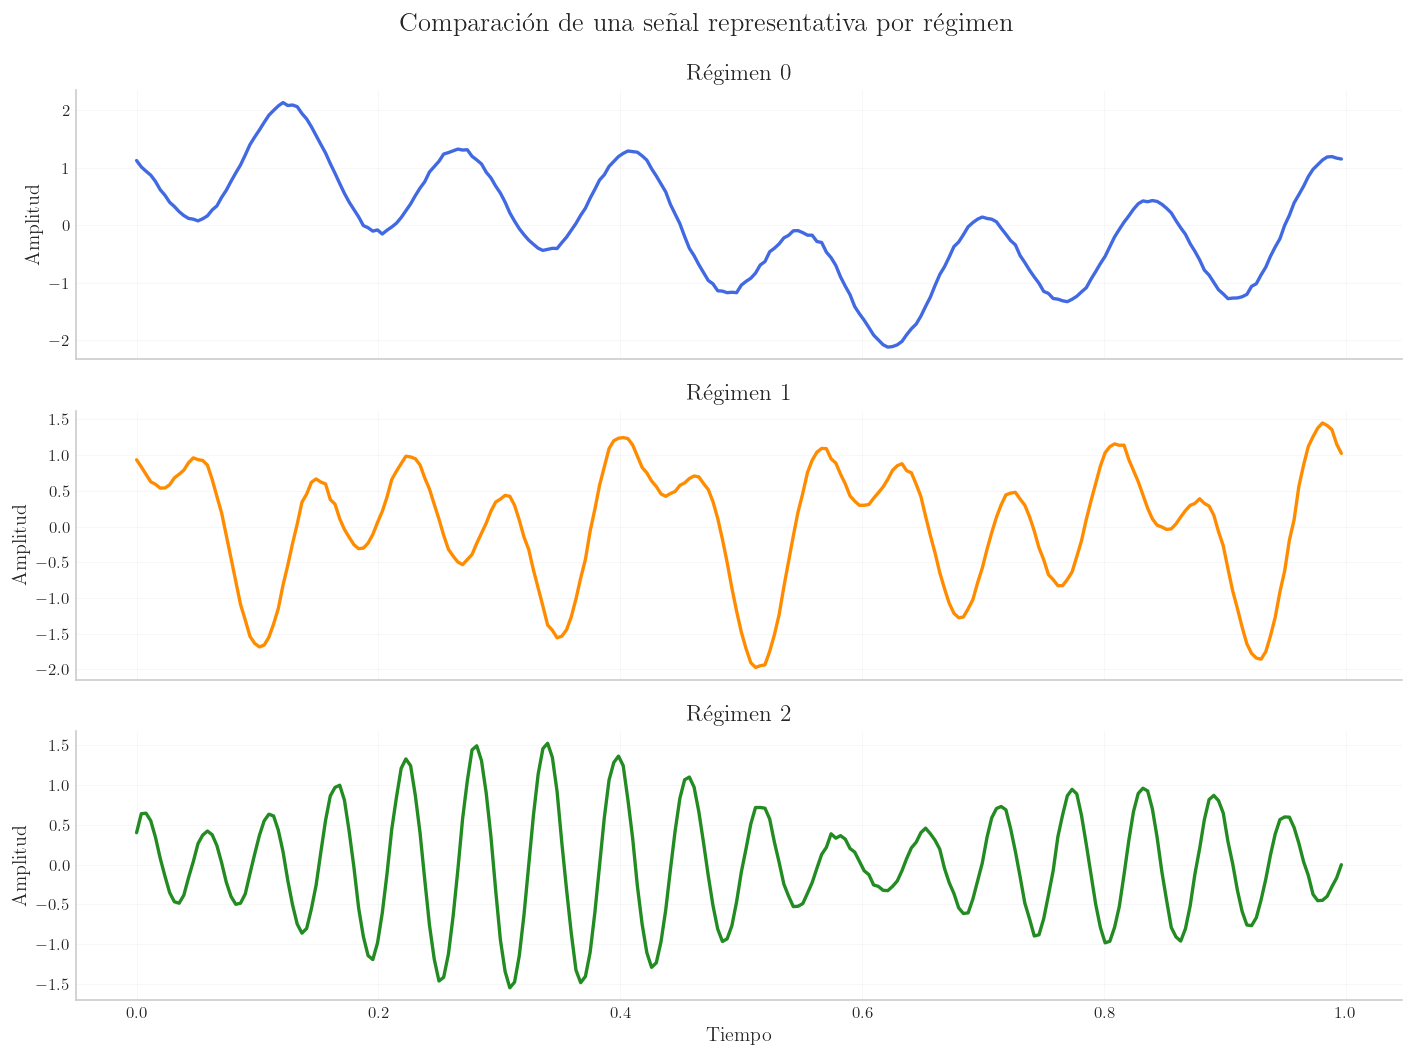

In [131]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12,9),
    sharex=True
)

colores = ["royalblue", "darkorange", "forestgreen"]

for regimen in [0,1,2]:

    indice = np.where(y == regimen)[0][0]

    axes[regimen].plot(
        t,
        X[indice],
        color=colores[regimen],
        linewidth=2
    )

    axes[regimen].set_title(f"Régimen {regimen}")

    axes[regimen].set_ylabel("Amplitud")

    axes[regimen].grid(alpha=0.3)

axes[-1].set_xlabel("Tiempo")

plt.suptitle(
    "Comparación de una señal representativa por régimen",
    fontsize=16
)

plt.tight_layout()

plt.show()

La figura anterior permite apreciar diferencias importantes entre los tres regímenes estudiados.

En el **Régimen 0** las oscilaciones son relativamente suaves y presentan una menor frecuencia.

A medida que aumenta el régimen de dispersión aparecen oscilaciones cada vez más rápidas, lo que indica la presencia de componentes de mayor frecuencia dentro de la señal.

Este comportamiento coincide con la descripción física presentada en el enunciado, donde el incremento del parámetro de dispersión produce un desplazamiento de las frecuencias hacia valores más altos.

# 5. Construcción de la capa de Fourier

Hasta este punto se ha estudiado el comportamiento de las señales en el dominio del tiempo. Las figuras anteriores muestran que las diferencias entre los distintos regímenes están relacionadas principalmente con la velocidad de sus oscilaciones.

Sin embargo, el enunciado indica que cada señal fue construida como una suma de funciones seno y coseno con diferentes frecuencias. Esto sugiere que, en lugar de analizar únicamente la señal en función del tiempo, también es posible representarla mediante una combinación de funciones base.

La Transformada de Fourier proporciona precisamente esta representación. En lugar de describir la señal mediante sus valores temporales, la expresa como una combinación de componentes senoidales de distintas frecuencias.

Por esta razón, la primera capa de la red neuronal será inicializada utilizando una base de Fourier. Posteriormente esta inicialización será comparada con una inicialización completamente aleatoria para estudiar cuál permite una reconstrucción más eficiente de las señales.

## Construcción de la base de Fourier

De acuerdo con el enunciado, la primera capa de la red debe tener dimensión

$$
256 \longrightarrow 2K,
$$

donde \(K=30\).

Cada frecuencia aporta dos funciones base:

- una función seno,
- una función coseno.

En consecuencia, la matriz de la primera capa estará formada por

$$
2K=60
$$

funciones base evaluadas sobre el vector temporal.

In [132]:
K = 30

W_fourier = []

for k in range(1, K + 1):

    W_fourier.append(np.sin(2 * np.pi * k * t))
    W_fourier.append(np.cos(2 * np.pi * k * t))

W_fourier = np.array(W_fourier)

print("=" * 50)
print("Base de Fourier construida correctamente")
print("=" * 50)
print(f"Número de frecuencias (K): {K}")
print(f"Dimensión de la matriz: {W_fourier.shape}")

Base de Fourier construida correctamente
Número de frecuencias (K): 30
Dimensión de la matriz: (60, 256)


La matriz obtenida contiene sesenta funciones base: treinta funciones seno y treinta funciones coseno.

Cada fila representa una componente de frecuencia distinta, mientras que las columnas corresponden a los diferentes instantes de tiempo en los cuales fue evaluada la función.

Esta matriz será utilizada como punto de partida para inicializar la primera capa de la red neuronal propuesta en el enunciado.